<a href="https://colab.research.google.com/github/kevinandrespardo2506-boop/inteligencia-artificial-2/blob/main/algortimomnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
# 1. Cargar el conjunto de datos MNIST (imágenes de dígitos escritos a mano del 0 al 9)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalizar los valores de los píxeles para que estén en un rango de [0.0, 1.0] en vez de [0, 255]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 3. Redimensionar las imágenes para añadir de forma explícita el canal de color (escala de grises = 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# 4. Definir la arquitectura secuencial de la red neuronal convolucional (CNN)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),                  # Especificar la forma tridimensional de entrada (28x28x1)
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),  # Capa convolucional para extraer patrones visuales
    layers.MaxPooling2D(pool_size=(2, 2)),            # Reducir las dimensiones a la mitad seleccionando el máximo
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),  # Segunda capa convolucional para patrones más complejos
    layers.MaxPooling2D(pool_size=(2, 2)),            # Segunda reducción de dimensiones
    layers.Flatten(),                                 # Convertir la matriz final de características a un vector plano
    layers.Dropout(0.5),                              # Apagar neuronas aleatoriamente para mitigar el sobreajuste
    layers.Dense(10, activation="softmax")            # Capa de salida con probabilidad para cada una de las 10 clases (0-9)
])

# 5. Compilar el modelo determinando optimizador, pérdida y métrica principal
model.compile(
    loss="sparse_categorical_crossentropy",            # Ideal para clasificación multiclase con objetivos enteros
    optimizer="adam",                                 # Algoritmo de optimización adaptable
    metrics=["accuracy"]                              # Guardar registro de la exactitud durante el entrenamiento
)

# 6. Entrenar el modelo utilizando los datos procesados
model.fit(X_train, y_train, batch_size=128, epochs=3, validation_split=0.1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.8921 - loss: 0.3553 - val_accuracy: 0.9770 - val_loss: 0.0831
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9668 - loss: 0.1089 - val_accuracy: 0.9842 - val_loss: 0.0570
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9753 - loss: 0.0817 - val_accuracy: 0.9870 - val_loss: 0.0459


In [4]:
# 1. Predecir las probabilidades correspondientes para cada clase del set de prueba
y_scores = model.predict(X_test)

# 2. Elegir la clase con mayor probabilidad como la predicción final del modelo
y_pred = np.argmax(y_scores, axis=1)

# 3. Calcular y mostrar el F1-Score ponderado para tener una métrica robusta
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score (Ponderado): {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
F1 Score (Ponderado): 0.9853


In [5]:
# 1. Binarizar las etiquetas de prueba para realizar la evaluación de curvas ROC multiclase (Uno contra el resto)
y_test_bin = label_binarize(y_test, classes=list(range(10)))

roc_data = []
# 2. Iterar sobre cada uno de los 10 dígitos posibles para obtener sus métricas ROC individuales
for i in range(10):
    # Obtener tasa de falsos positivos (FPR) y tasa de verdaderos positivos (TPR)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    # Calcular el Área Bajo la Curva (AUC) correspondiente
    roc_auc = auc(fpr, tpr)
    # Consolidar los resultados representativos en un diccionario
    roc_data.append({
        'Clase/Dígito': i,
        'AUC (Área bajo la curva)': round(roc_auc, 4),
        'FPR Promedio': round(np.mean(fpr), 4),
        'TPR Promedio': round(np.mean(tpr), 4)
    })

# 3. Convertir el resumen de datos ROC en un DataFrame para mostrar la tabla
df_roc = pd.DataFrame(roc_data)
display(df_roc)

,Clase/Dígito,AUC (Área bajo la curva),FPR Promedio,TPR Promedio
0,0,0.9999,0.0050,0.4083
1,1,1.0000,0.0083,0.4028
2,2,0.9999,0.0098,0.4821
3,3,0.9999,0.0062,0.4110
4,4,0.9999,0.0067,0.4103
5,5,0.9999,0.0098,0.3949
6,6,0.9997,0.0080,0.4624
7,7,0.9998,0.0179,0.5449
8,8,0.9998,0.0103,0.5690
9,9,0.9998,0.0142,0.6989


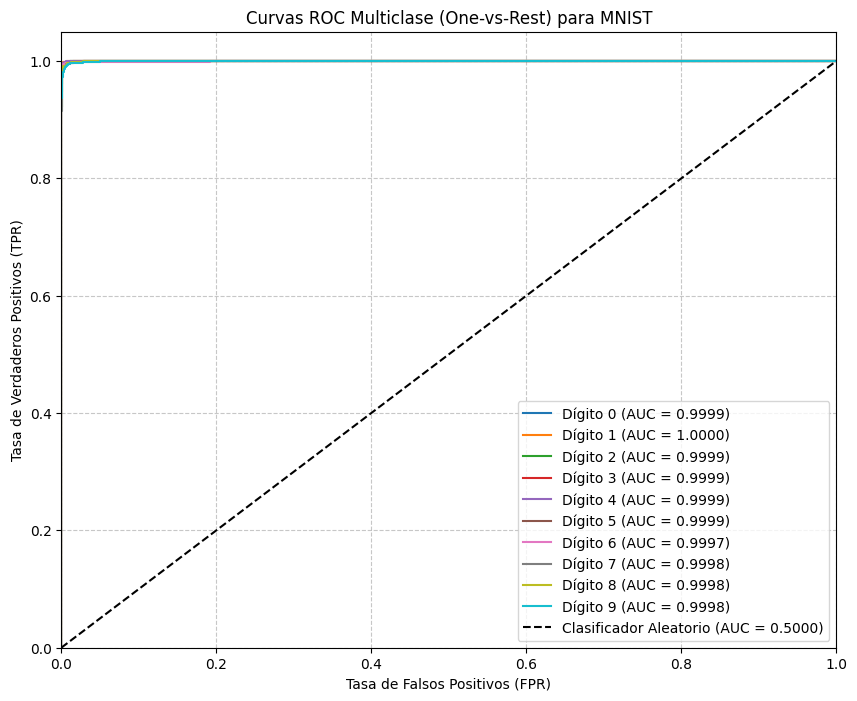

In [7]:
# 1. Crear una figura para visualizar la gráfica de curvas ROC
plt.figure(figsize=(10, 8))

# 2. Iterar sobre cada dígito para graficar su curva individualmente
for i in range(10):
    # Obtener la tasa de falsos positivos (FPR) y de verdaderos positivos (TPR) para el dígito actual
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    # Calcular el Área Bajo la Curva (AUC)
    roc_auc = auc(fpr, tpr)
    # Graficar la curva para esta clase asignando una etiqueta explicativa
    plt.plot(fpr, tpr, label=f'Dígito {i} (AUC = {roc_auc:.4f})')

# 3. Dibujar la línea de referencia diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5000)')

# 4. Configurar etiquetas, límites de los ejes, título y cuadrícula para mejor visualización
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase (One-vs-Rest) para MNIST')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Mostrar la gráfica final en pantalla
plt.show()